In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv("European_Bank.csv")

In [3]:
df.head(10)

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,2025,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,2025,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,2025,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,2025,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,2025,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [5]:
df.shape

(10000, 14)

In [6]:
df.isnull().sum()

Year               0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
# understanding the target
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [8]:
df['HasCrCard'].value_counts()

HasCrCard
1    7055
0    2945
Name: count, dtype: int64

In [9]:
df['IsActiveMember'].value_counts()

IsActiveMember
1    5151
0    4849
Name: count, dtype: int64

In [10]:
df['NumOfProducts'].value_counts()

NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,10000.0,2.025000e+03,0.000000,2025.00,2025.00,2.025000e+03,2.025000e+03,2025.00
CustomerId,10000.0,1.569094e+07,71936.186123,15565701.00,15628528.25,1.569074e+07,1.575323e+07,15815690.00
CreditScore,10000.0,6.505288e+02,96.653299,350.00,584.00,6.520000e+02,7.180000e+02,850.00
Age,10000.0,3.892180e+01,10.487806,18.00,32.00,3.700000e+01,4.400000e+01,92.00
Tenure,10000.0,5.012800e+00,2.892174,0.00,3.00,5.000000e+00,7.000000e+00,10.00
Balance,10000.0,7.648589e+04,62397.405202,0.00,0.00,9.719854e+04,1.276442e+05,250898.09
NumOfProducts,10000.0,1.530200e+00,0.581654,1.00,1.00,1.000000e+00,2.000000e+00,4.00
HasCrCard,10000.0,7.055000e-01,0.455840,0.00,0.00,1.000000e+00,1.000000e+00,1.00
IsActiveMember,10000.0,5.151000e-01,0.499797,0.00,0.00,1.000000e+00,1.000000e+00,1.00
EstimatedSalary,10000.0,1.000902e+05,57510.492818,11.58,51002.11,1.001939e+05,1.493882e+05,199992.48


HANDELING OUTLIERS

In [42]:
mulcols=['Age','CreditScore','Balance','EstimatedSalary']

AGE

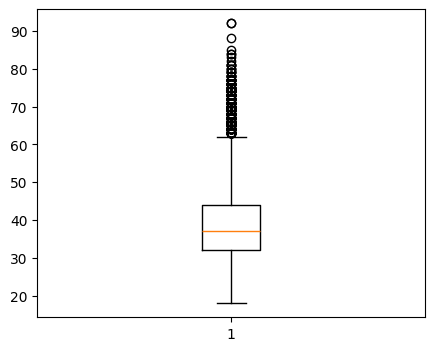

In [45]:
plt.figure(figsize=(5,4))
plt.boxplot(x=df["Age"]);

In [46]:
age=df['Age'].to_list()

In [47]:
Q1 = np.percentile(age,25, interpolation ="midpoint")
Q2 = np.percentile(age,50, interpolation ="midpoint")
Q3 = np.percentile(age,75, interpolation ="midpoint")

In [48]:
IQR=Q3-Q1

In [49]:
print("Age Outliers")
print("Minimum:", Q1 - 1.5 * IQR)
print("Maximum:", Q3 + 1.5 * IQR)

Age Outliers
Minimum: 14.0
Maximum: 62.0


In [50]:
outliers_age=[]
for i in age:
    if i > Q3 + 1.5 * IQR or Q1 - 1.5 * IQR:
        outliers_age.append(i)
outliers_age

[42,
 41,
 42,
 39,
 43,
 44,
 50,
 29,
 44,
 27,
 31,
 24,
 34,
 25,
 35,
 45,
 58,
 24,
 45,
 24,
 41,
 32,
 38,
 46,
 38,
 25,
 36,
 44,
 43,
 29,
 39,
 36,
 41,
 42,
 29,
 45,
 31,
 33,
 36,
 41,
 40,
 51,
 61,
 49,
 61,
 32,
 27,
 39,
 38,
 37,
 44,
 36,
 33,
 41,
 42,
 43,
 45,
 19,
 66,
 51,
 35,
 27,
 33,
 56,
 26,
 36,
 34,
 43,
 35,
 21,
 58,
 29,
 37,
 25,
 36,
 21,
 55,
 32,
 33,
 41,
 34,
 32,
 36,
 34,
 46,
 75,
 22,
 30,
 46,
 28,
 44,
 45,
 36,
 29,
 42,
 35,
 41,
 29,
 22,
 34,
 40,
 44,
 31,
 36,
 65,
 46,
 32,
 36,
 33,
 35,
 30,
 39,
 42,
 36,
 28,
 30,
 37,
 41,
 31,
 34,
 34,
 39,
 39,
 48,
 28,
 42,
 52,
 56,
 41,
 24,
 34,
 33,
 38,
 25,
 39,
 50,
 34,
 40,
 48,
 35,
 44,
 34,
 43,
 52,
 31,
 21,
 29,
 37,
 44,
 32,
 32,
 48,
 42,
 37,
 43,
 57,
 33,
 28,
 73,
 33,
 22,
 30,
 49,
 36,
 29,
 31,
 24,
 41,
 39,
 24,
 29,
 27,
 44,
 30,
 40,
 35,
 30,
 36,
 40,
 55,
 45,
 65,
 45,
 42,
 50,
 32,
 39,
 37,
 30,
 34,
 41,
 36,
 40,
 32,
 29,
 35,
 32,
 37,
 57,
 35,


In [51]:
df[df['Age'].isin(outliers_age)]

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2025,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,2025,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,2025,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,2025,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


CREDITSCORE

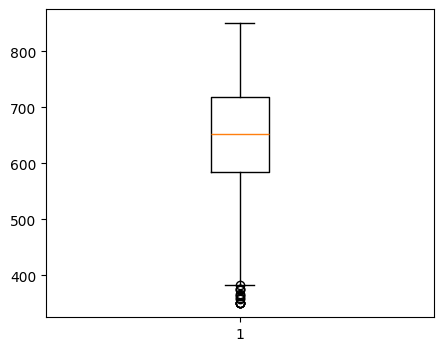

In [43]:
plt.figure(figsize=(5,4))
plt.boxplot(x=df["CreditScore"]);

In [44]:
credit=df['CreditScore'].to_list()

In [15]:
Q1 = np.percentile(credit,25, interpolation ="midpoint")
Q2 = np.percentile(credit,50, interpolation ="midpoint")
Q3 = np.percentile(credit,75, interpolation ="midpoint")

In [16]:
IQR=Q3-Q1

In [17]:
print("CreditScore Outliers")
print("Minimum:", Q1 - 1.5 * IQR)
print("Maximum:", Q3 + 1.5 * IQR)

CreditScore Outliers
Minimum: 383.0
Maximum: 919.0


In [18]:
outliers_credit=[]
for i in credit:
    if i > Q3 + 1.5 * IQR or i < Q1 - 1.5 * IQR:
        outliers_credit.append(i)
outliers_credit

[376, 376, 363, 359, 350, 350, 358, 351, 365, 367, 350, 350, 382, 373, 350]

In [19]:
df[df['CreditScore'].isin(outliers_credit)]

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
7,2025,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
942,2025,15804586,Lin,376,France,Female,46,6,0.00,1,1,0,157333.69,1
1193,2025,15779947,Thomas,363,Spain,Female,28,6,146098.43,3,1,0,100615.14,1
1405,2025,15612494,Panicucci,359,France,Female,44,6,128747.69,1,1,0,146955.71,1
1631,2025,15685372,Azubuike,350,Spain,Male,54,1,152677.48,1,1,1,191973.49,1
1838,2025,15758813,Campbell,350,Germany,Male,39,0,109733.20,2,0,0,123602.11,1
1962,2025,15692416,Aikenhead,358,Spain,Female,52,8,143542.36,3,1,0,141959.11,1
2473,2025,15679249,Chou,351,Germany,Female,57,4,163146.46,1,1,0,169621.69,1
2579,2025,15597896,Ozoemena,365,Germany,Male,30,0,127760.07,1,1,0,81537.85,1
8154,2025,15791533,Ch'ien,367,Spain,Male,42,6,93608.28,1,1,0,168816.73,1


BALANCE

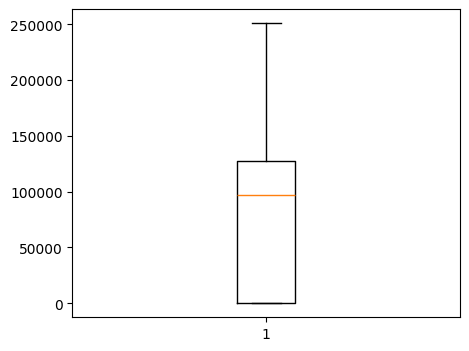

In [20]:
plt.figure(figsize=(5,4))
plt.boxplot(x=df["Balance"]);

In [21]:
balance=df['Balance'].to_list()

In [22]:
Q1 = np.percentile(balance,25, interpolation ="midpoint")
Q2 = np.percentile(balance,50, interpolation ="midpoint")
Q3 = np.percentile(balance,75, interpolation ="midpoint")

In [23]:
IQR=Q3-Q1

In [24]:
print("Balance Outliers")
print("Minimum:", Q1 - 1.5 * IQR)
print("Maximum:", Q3 + 1.5 * IQR)

Balance Outliers
Minimum: -191469.06
Maximum: 319115.1


In [25]:
outliers_balance=[]
for i in balance :
    if i > Q3 + 1.5 * IQR or i <  Q1 - 1.5 * IQR:
        outliers_balance.append(i)
outliers_balance

[]

In [26]:
df[df['Balance'].isin(outliers_balance)]

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


ESTIMATED SALARY

{'whiskers': [<matplotlib.lines.Line2D at 0x25567731e80>,
 'caps': [<matplotlib.lines.Line2D at 0x25567733800>,
 'boxes': [<matplotlib.lines.Line2D at 0x255677327b0>],
 'medians': [<matplotlib.lines.Line2D at 0x25567733dd0>],
 'fliers': [<matplotlib.lines.Line2D at 0x2556779c140>],
 'means': []}

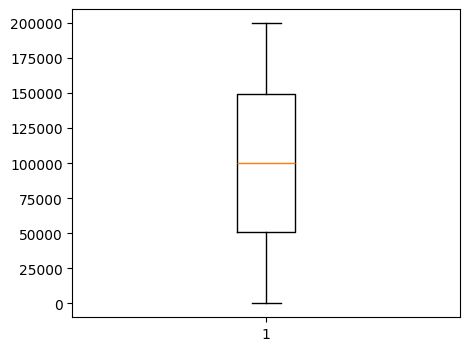

In [27]:
plt.figure(figsize=(5,4))
plt.boxplot(x=df["EstimatedSalary"])

In [28]:
salary = df['EstimatedSalary'].to_list()

In [29]:
Q1 = np.percentile(salary,25, interpolation ="midpoint")
Q2 = np.percentile(salary,50, interpolation ="midpoint")
Q3 = np.percentile(salary,75, interpolation ="midpoint")

In [30]:
IQR = Q3 -Q1 

In [31]:
print("Estimated_Salary Outliers")
print("Minimun:", Q1 - 1.5 * IQR)
print("Maximum:", Q3 + 1.5 * IQR)

Estimated_Salary Outliers
Minimun: -96605.77250000002
Maximum: 296990.7675


In [32]:
outliers_estimated_salary=[]
for i in salary:
    if i > Q3 + 1.5 * IQR or i < Q1 - 1.5 * IQR:
        outliers_estimated_salary.append(i)

outliers_estimated_salary

[]

In [33]:
df[df['EstimatedSalary'].isin(outliers_estimated_salary)]

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited


In [34]:
df.dtypes

Year                 int64
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Gender              object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

In [35]:
df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Geography', 'Gender',
       'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

VISUALISATIONS

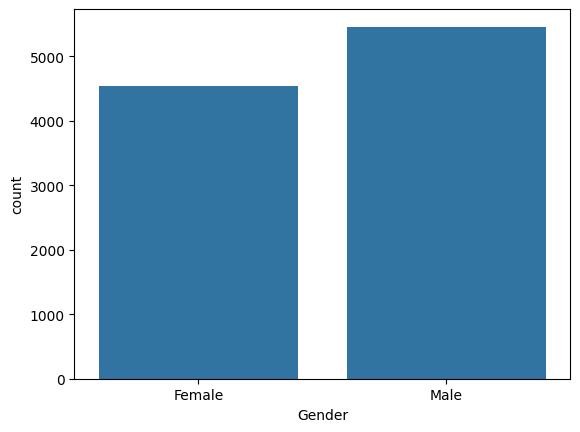

In [36]:
sns.countplot(data=df, x='Gender')
plt.show()

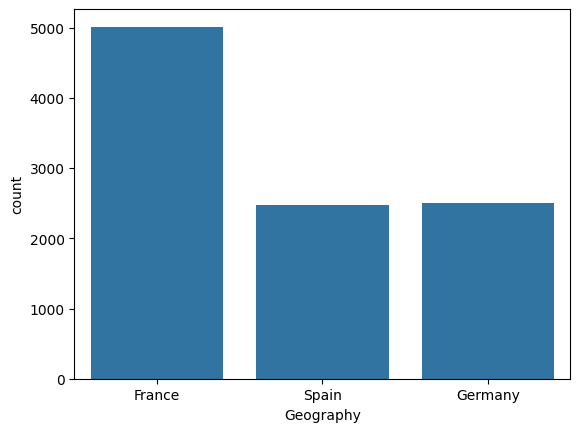

In [37]:
sns.countplot(data=df, x='Geography')
plt.show()

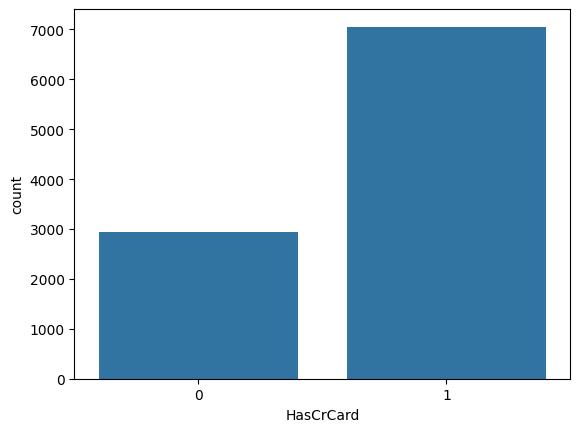

In [38]:
sns.countplot(data=df, x='HasCrCard')
plt.show()

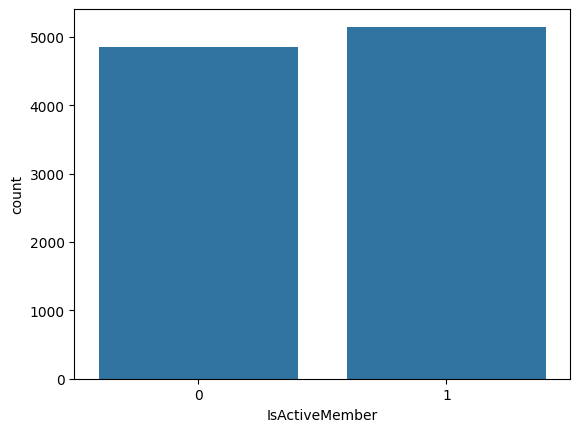

In [39]:
sns.countplot(data=df, x='IsActiveMember')
plt.show()

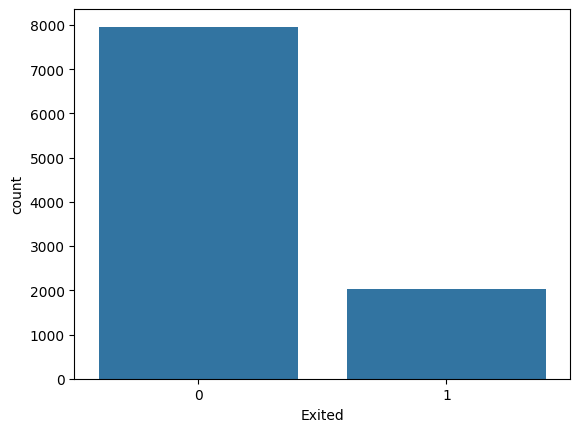

In [40]:
sns.countplot(data=df, x='Exited')
plt.show()

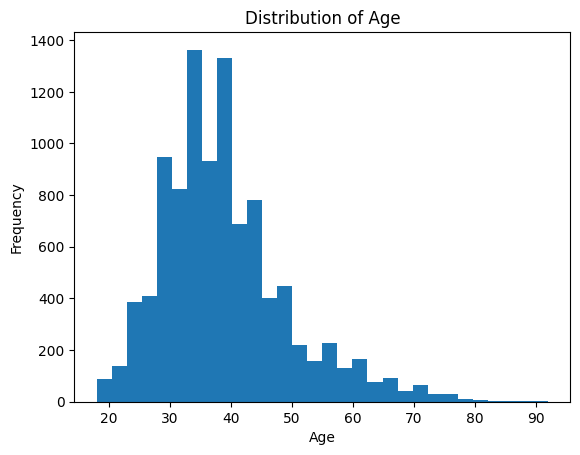

In [52]:
# Histogram of Age
plt.hist(df['Age'],bins=30)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

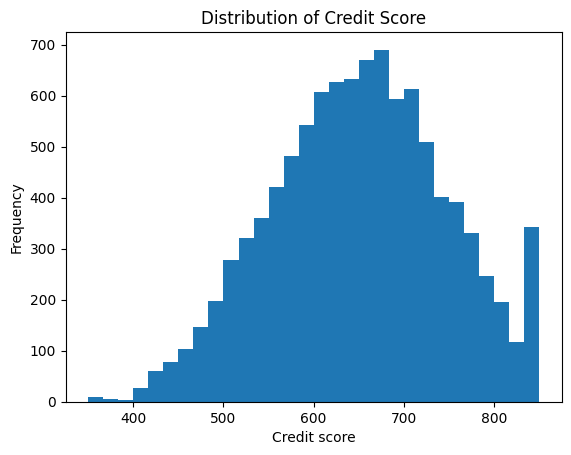

In [53]:
# Histogram of CreditScore
plt.hist(df['CreditScore'],bins=30)
plt.title('Distribution of Credit Score')
plt.xlabel('Credit score')
plt.ylabel('Frequency')
plt.show()

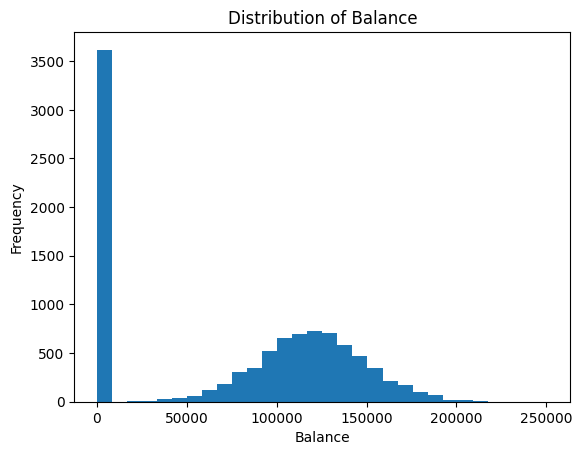

In [54]:
# Histogram of Balance
plt.hist(df['Balance'],bins=30)
plt.title('Distribution of Balance')
plt.xlabel('Balance')
plt.ylabel('Frequency')
plt.show()

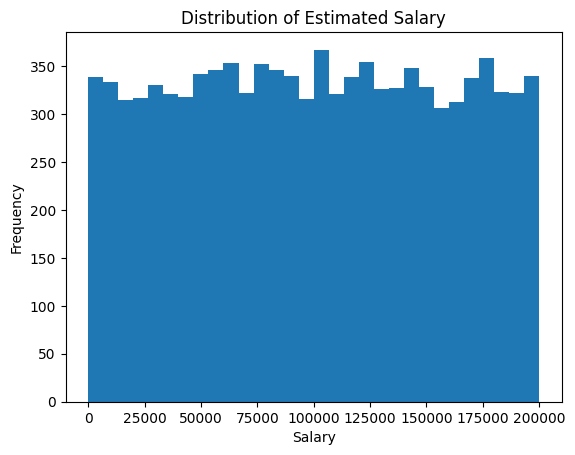

In [55]:
# Histogram of Estimated Salary
plt.hist(df['EstimatedSalary'],bins=30)
plt.title('Distribution of Estimated Salary')
plt.xlabel('Salary')
plt.ylabel('Frequency')
plt.show()

comparing the imp fields with the target

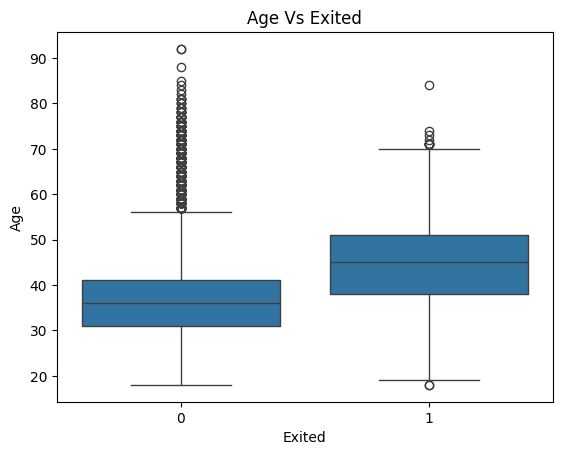

In [57]:
sns.boxplot(x='Exited', y='Age', data=df)
plt.title("Age Vs Exited")
plt.show()

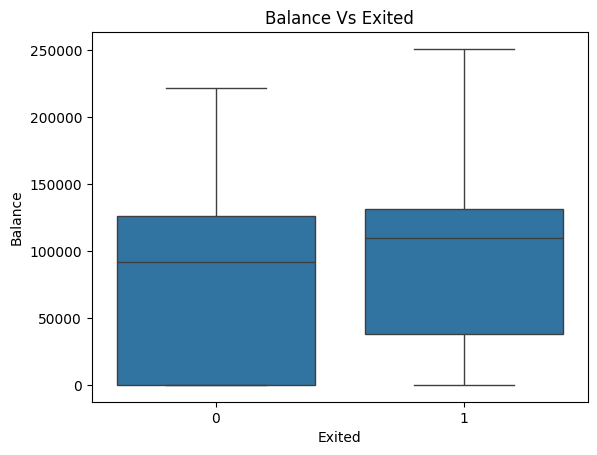

In [58]:
sns.boxplot(x='Exited', y='Balance', data=df)
plt.title("Balance Vs Exited")
plt.show()

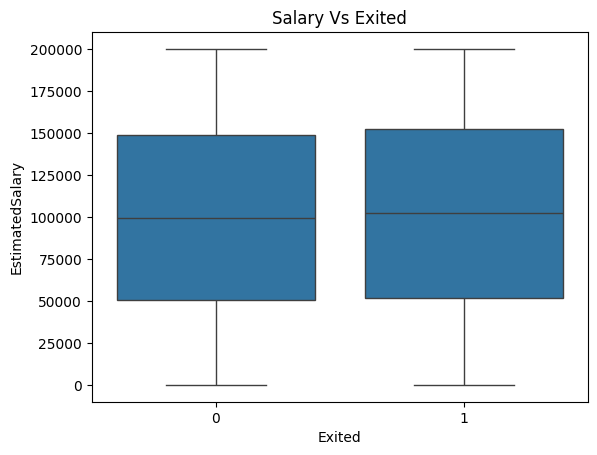

In [ ]:
sns.boxplot(x='Exited', y='EstimatedSalary', data=df)
plt.title("Salary Vs Exited")
plt.show()

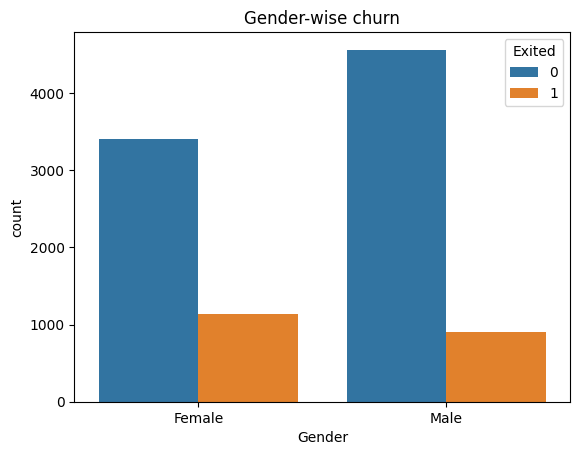

In [ ]:
sns.countplot(data=df,x='Gender',hue='Exited', )
plt.title("Gender-wise churn")
plt.show()

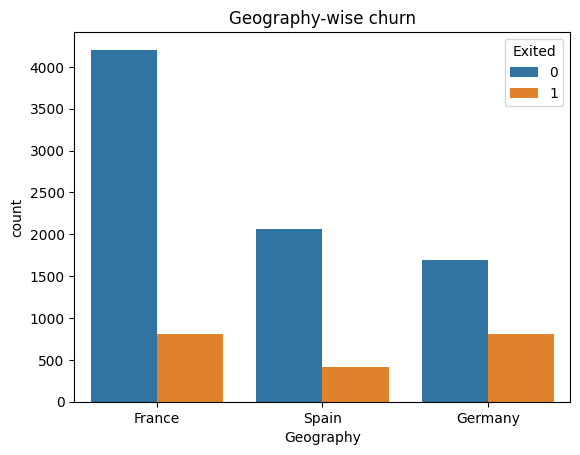

In [64]:
sns.countplot(data=df,x='Geography',hue='Exited', )
plt.title("Geography-wise churn")
plt.show()

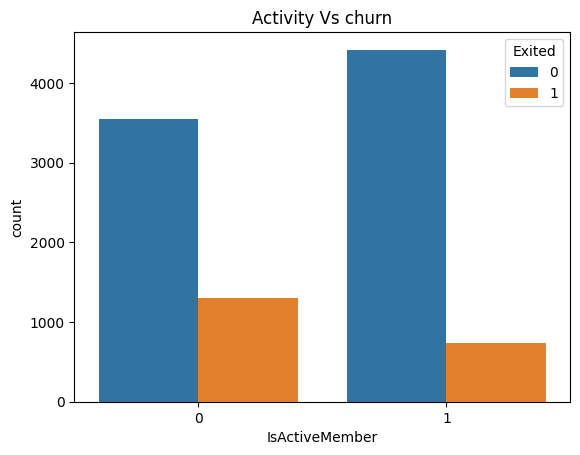

In [65]:
sns.countplot(data=df,x='IsActiveMember',hue='Exited', )
plt.title("Activity Vs churn")
plt.show()

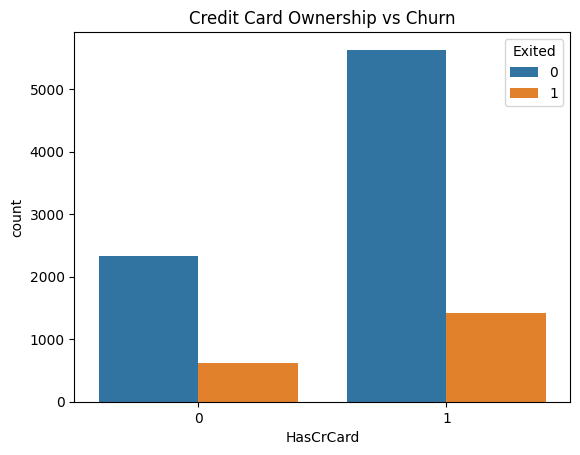

In [66]:
sns.countplot(data=df,x='HasCrCard',hue='Exited', )
plt.title("Credit Card Ownership vs Churn")
plt.show()

In [68]:
df.drop(['Year','Surname'], axis=1, inplace=True)

In [69]:
df.head()

,CustomerId,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [70]:
font_size = 15 
plt.rcParams['axes.labelsize']= font_size
plt.rcParams['axes.titlesize']= font_size + 2
plt.rcParams['xtick.labelsize']= font_size - 2
plt.rcParams['ytick.labelsize']= font_size - 2
plt.rcParams['legend.fontsize']= font_size - 2

In [71]:
colors=['Green','pink','red','cyan']

C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\4157866402.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Exited', data=df, palette=colors, ax=ax)
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\4157866402.py:3: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.countplot(x='Exited', data=df, palette=colors, ax=ax)
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\4157866402.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Retained', "Churned"])


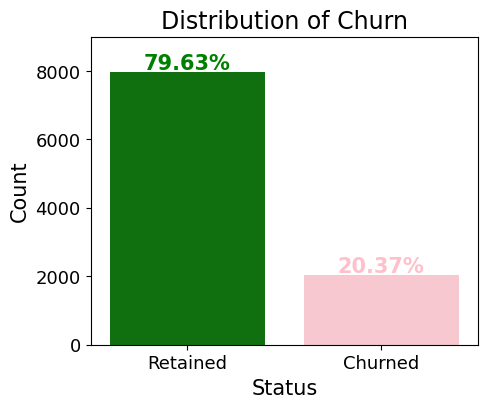

In [74]:
fig, ax = plt.subplots(figsize=(5,4))

sns.countplot(x='Exited', data=df, palette=colors, ax=ax)

for index, value in enumerate(df['Exited'].value_counts()):
    label='{}%'.format(round((value / df['Exited'].shape[0]) * 100,2))
    ax.annotate(label,
                xy=(index, value + 250),
                ha='center',
                va='center',
                color=colors[index],
                fontweight='bold',
                size=font_size)
    
ax.set_xticklabels(['Retained', "Churned"])
ax.set_xlabel('Status')
ax.set_ylabel('Count')
ax.set_title("Distribution of Churn")
ax.set_ylim([0,9000]);

In [75]:
categorical=['Geography','Gender','Tenure','NumOfProducts','HasCrCard', 'IsActiveMember']

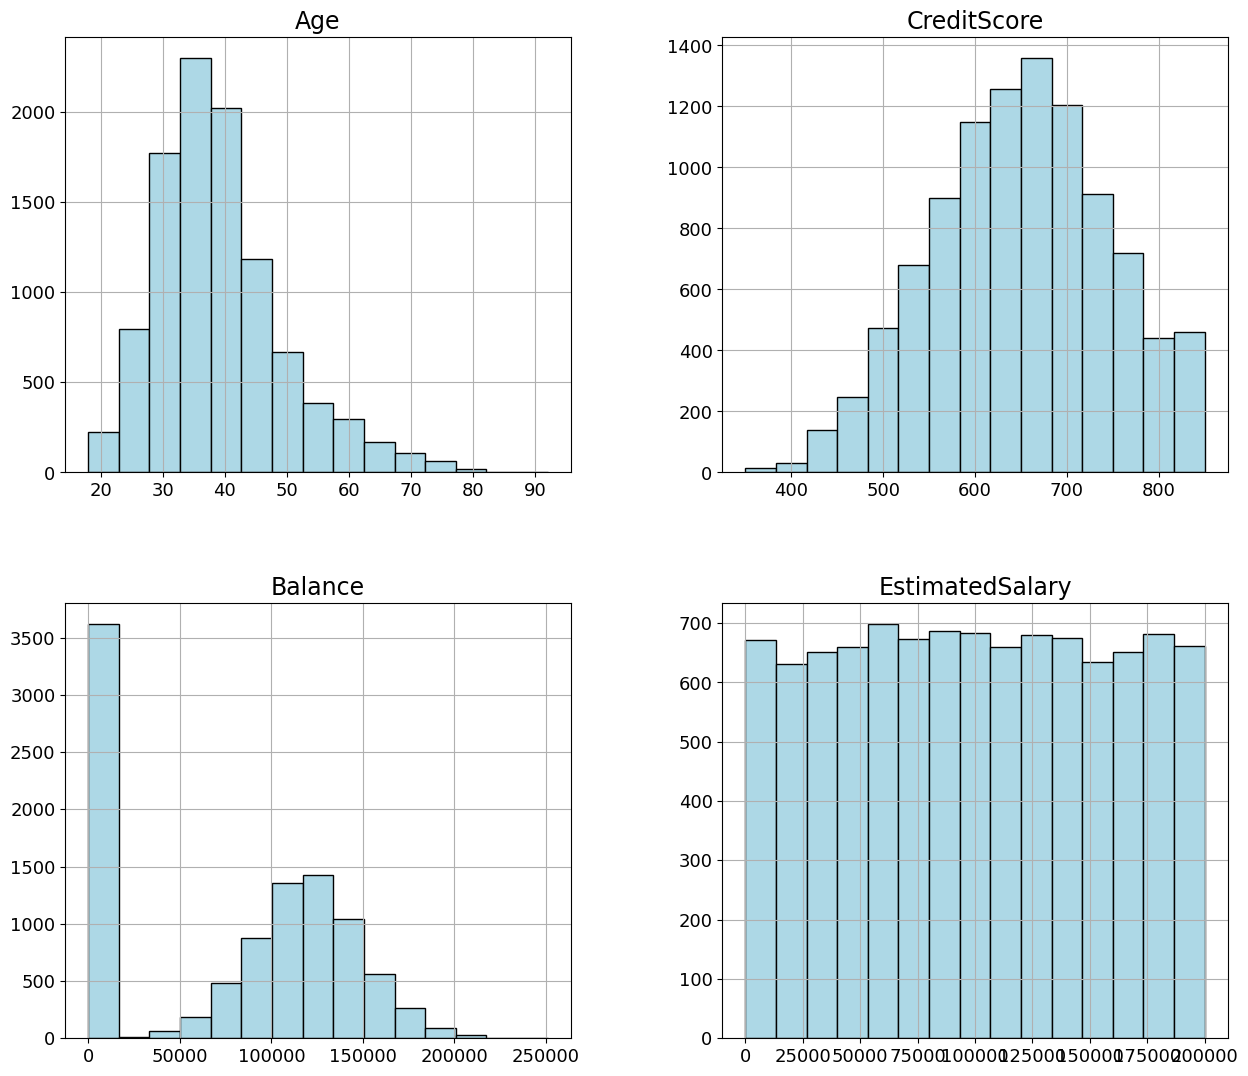

In [76]:
df[mulcols].hist(figsize=(15,13),
                 bins=15,
                 layout=(2,2),
                 color='lightblue',
                 edgecolor='black',
                 linewidth=1.0);

In [77]:
df[mulcols].corr()

,Age,CreditScore,Balance,EstimatedSalary
Age,1.000000,-0.003965,0.028308,-0.007201
CreditScore,-0.003965,1.000000,0.006268,-0.001384
Balance,0.028308,0.006268,1.000000,0.012797
EstimatedSalary,-0.007201,-0.001384,0.012797,1.000000


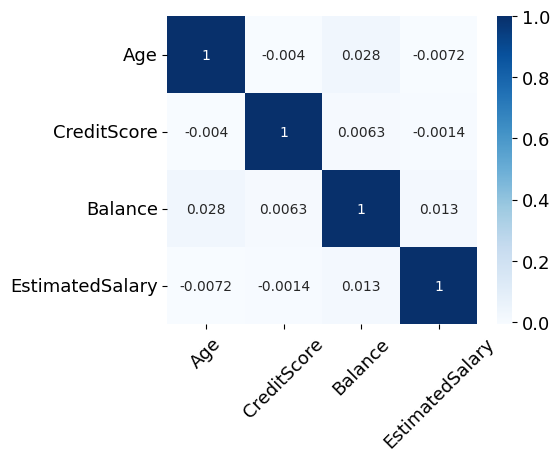

In [79]:
fig, ax =plt.subplots(figsize=(5,4))

sns.heatmap(df[mulcols].corr(),
            annot=True,
            annot_kws={'fontsize':10},
            cmap='Blues',
            ax=ax)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=360);

In [94]:
def plot_continuous(df, feature):

    df_func = df.copy()
    df_func['Exited'] = df_func['Exited'].astype('category')

    df_churned = df_func[df_func['Exited']==1]
    df_retained = df_func[df_func['Exited']==0]

    fig, (ax1, ax2)=plt.subplots(2,
                                 figsize=(9,7),
                                 sharex=True,
                                 gridspec_kw={"height_ratios":(.7,.3)})
    
    colors= ['#1f77b4', '#ff7f0e']

    for sub_df, color, label in zip([df_retained, df_churned], colors, ['Retained','Churned']):
        sns.histplot(data=sub_df,
                     x=feature,
                     bins=15,
                     color=color,
                     alpha=0.6,
                     edgecolor='firebrick',
                     label=label,
                     kde=False,
                     ax=ax1)
    ax1.legend()

    sns.boxplot(x=feature, y='Exited', data= df_func, palette=colors, ax=ax2)
    ax2.set_ylabel('')
    ax2.set_yticklabels(['Retained','Churned'])
    plt.tight_layout()
    plt.show()

    

C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\1016974505.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=feature, y='Exited', data= df_func, palette=colors, ax=ax2)
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\1016974505.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(['Retained','Churned'])


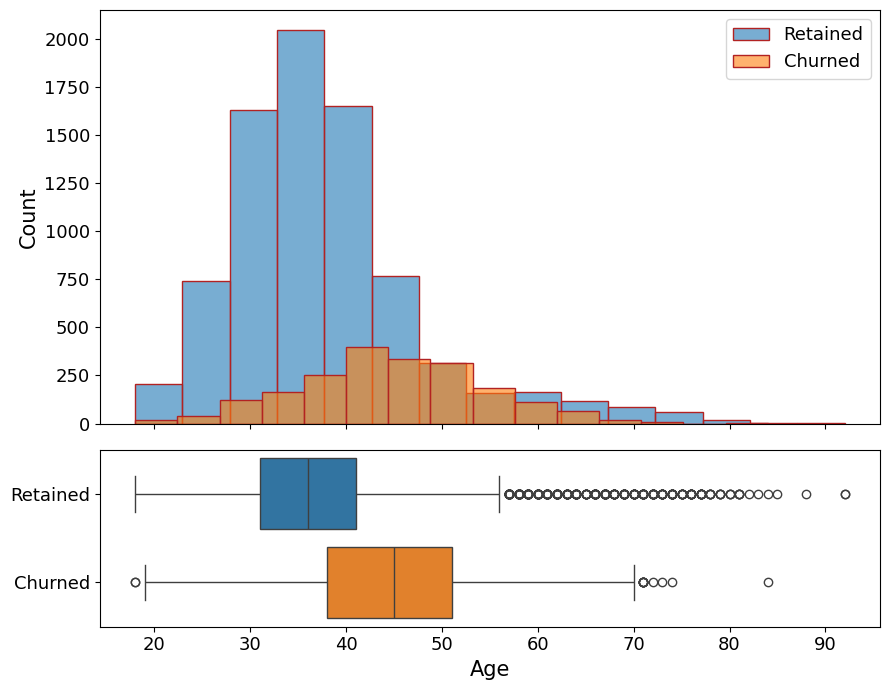

In [95]:
plot_continuous(df,'Age')

C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\1016974505.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=feature, y='Exited', data= df_func, palette=colors, ax=ax2)
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\1016974505.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(['Retained','Churned'])


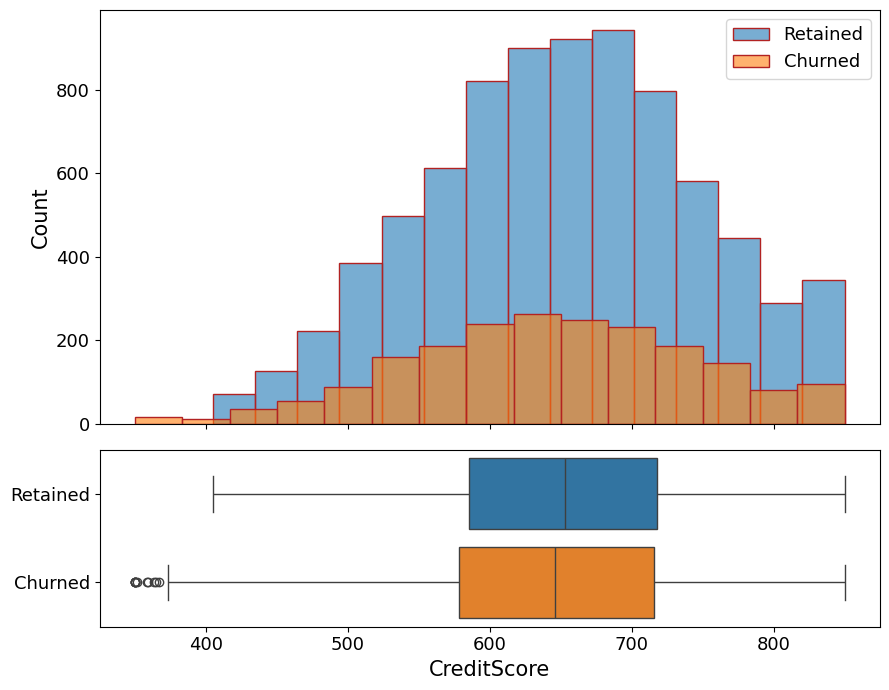

In [96]:
plot_continuous(df,'CreditScore')

C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\1016974505.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=feature, y='Exited', data= df_func, palette=colors, ax=ax2)
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\1016974505.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(['Retained','Churned'])


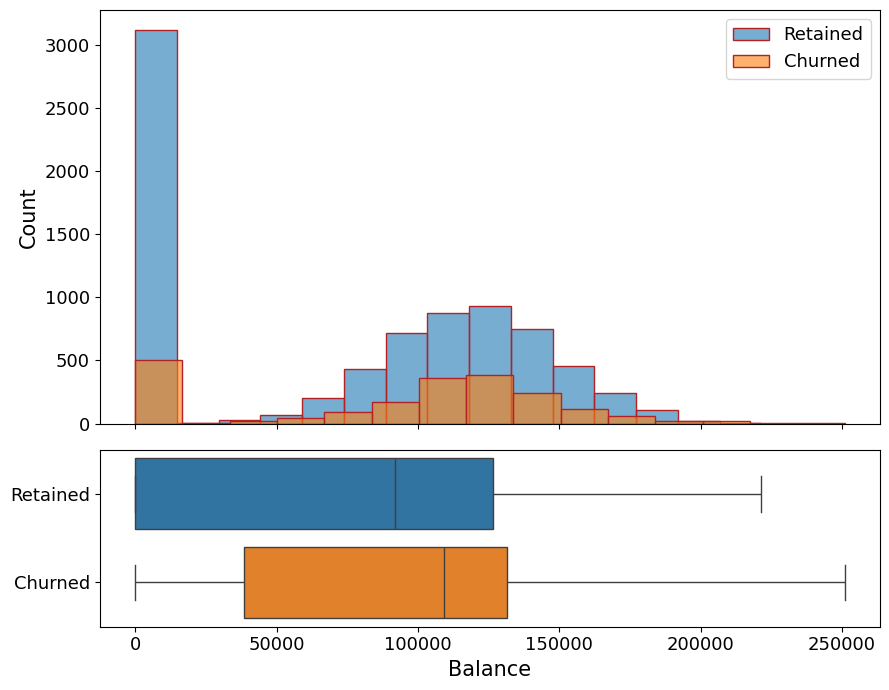

In [97]:
plot_continuous(df,'Balance')

C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\1016974505.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=feature, y='Exited', data= df_func, palette=colors, ax=ax2)
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\1016974505.py:30: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_yticklabels(['Retained','Churned'])


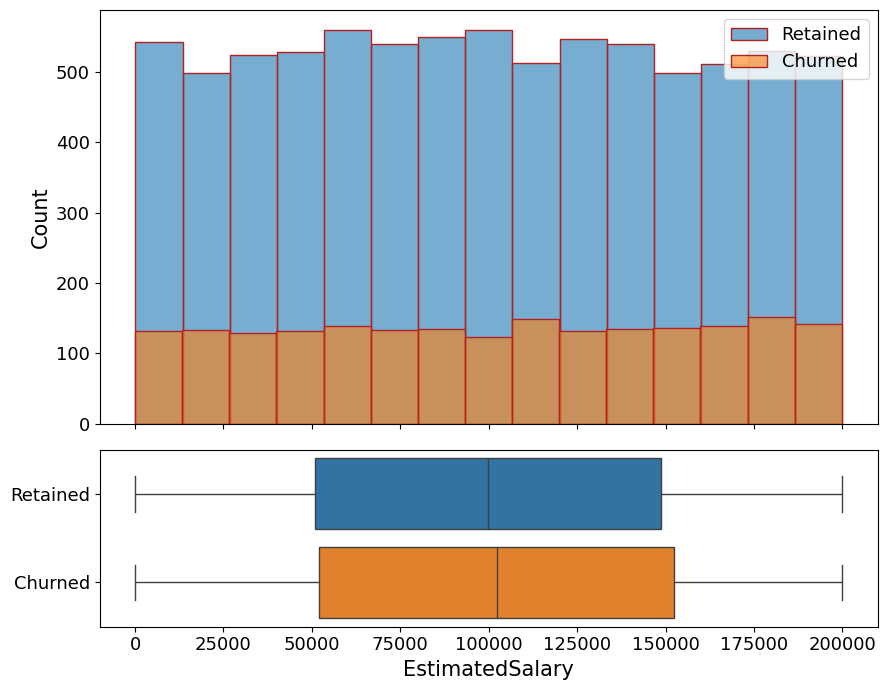

In [98]:
plot_continuous(df,'EstimatedSalary')

In [99]:
font_size = 16
plt.rcParams['axes.labelsize']= font_size
plt.rcParams['axes.titlesize']= font_size + 2
plt.rcParams['xtick.labelsize']= font_size - 2
plt.rcParams['ytick.labelsize']= font_size - 2
plt.rcParams['legend.fontsize']= font_size - 2

colors_cat = ['cyan','steelblue','seagreen','black','darkorange','purple','firebrick','slategrey','red','yellow','pink']

In [100]:
categorical

['Geography',
 'Gender',
 'Tenure',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember']

C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\1527970246.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=column, data=df, palette=colors_cat)
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\1527970246.py:7: UserWarning: The palette list has more values (11) than needed (3), which may not be intended.
  sns.countplot(x=column, data=df, palette=colors_cat)
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\1527970246.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=column, data=df, palette=colors_cat)
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\1527970246.py:7: UserWarning: The palette list has more values (11) than needed (2), which may not be intended.
  sns.count

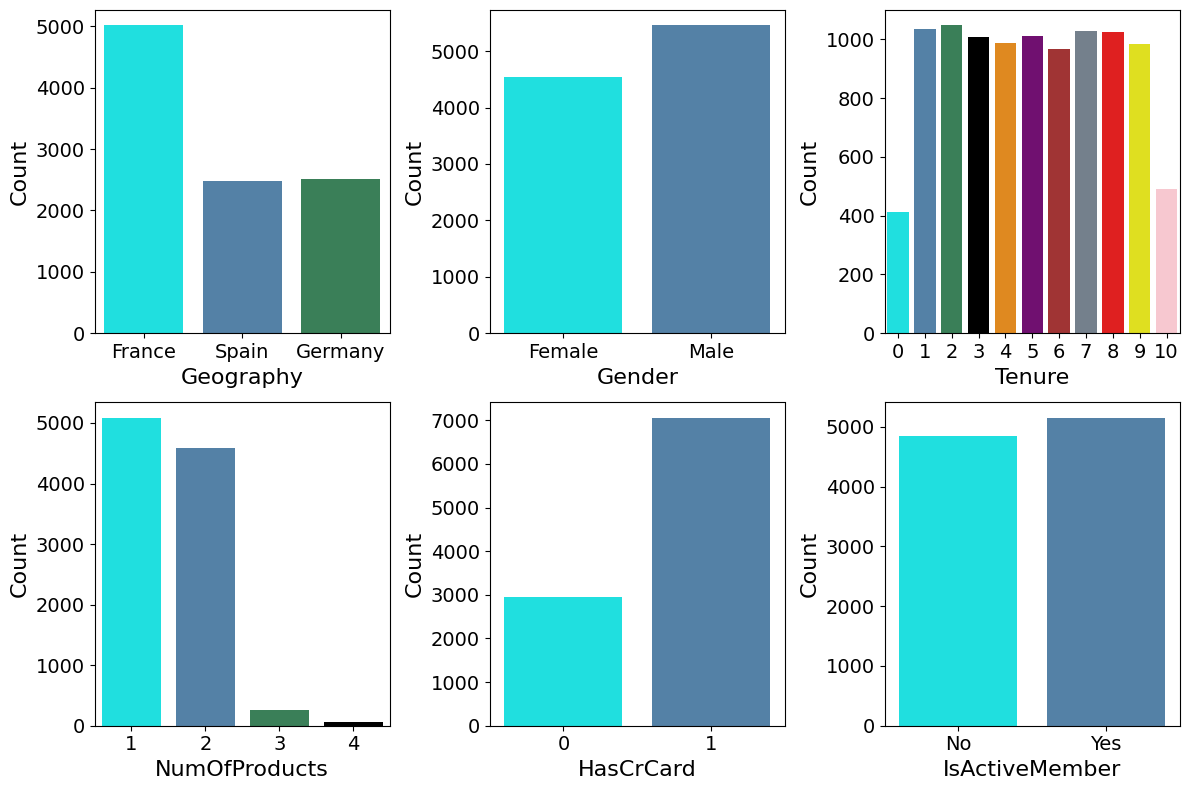

In [102]:
df_cat = df[categorical]
fig, ax = plt.subplots(2,3, figsize=(12,8))

for index, column in enumerate(df_cat.columns):

    plt.subplot(2, 3, index + 1)
    sns.countplot(x=column, data=df, palette=colors_cat)

    plt.ylabel('Count')
    if (column == 'HasCrcard' or column=='IsActiveMember'):
        plt.xticks([0,1], ['No','Yes'])

plt.tight_layout();

In [107]:
def plot_categorical(feature):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

    sns.countplot(x=feature,
                  hue='Exited',
                  data=df,
                  palette=colors_cat,
                  ax=ax1)
    ax2.set_ylabel('Count')
    ax1.legend(labels=['Retained','Churned'])

    sns.barplot(x=feature,
                y='Exited',
                data=df,
                palette=colors_cat,
                ax=ax2)
    ax2.set_ylabel('Churn rate')

    if(feature == 'HasCrCard' or feature == 'IsActiveMember'):
        ax1.set_xticklabels(['No','Yes'])
        ax2.set_xticklabels(['No','Yes'])

plt.tight_layout();

<Figure size 640x480 with 0 Axes>

C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\2361493296.py:4: UserWarning: The palette list has more values (11) than needed (2), which may not be intended.
  sns.countplot(x=feature,
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\2361493296.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature,
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\2361493296.py:12: UserWarning: The palette list has more values (11) than needed (3), which may not be intended.
  sns.barplot(x=feature,


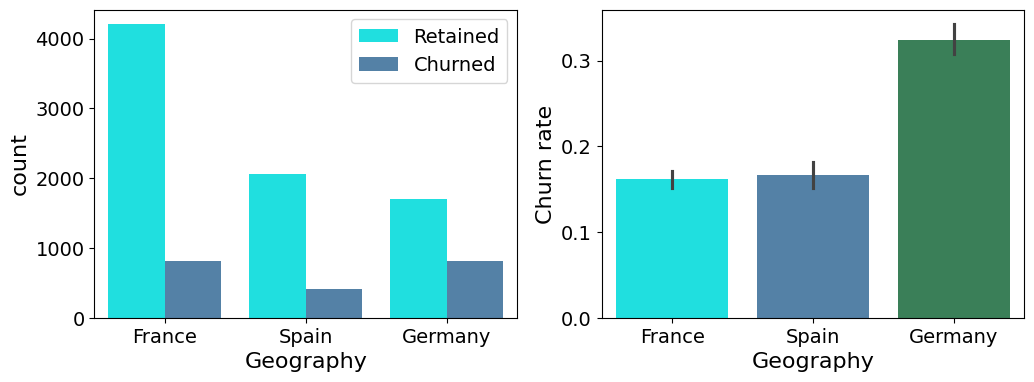

In [108]:
plot_categorical('Geography')

C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\2361493296.py:4: UserWarning: The palette list has more values (11) than needed (2), which may not be intended.
  sns.countplot(x=feature,
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\2361493296.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature,
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\2361493296.py:12: UserWarning: The palette list has more values (11) than needed (2), which may not be intended.
  sns.barplot(x=feature,


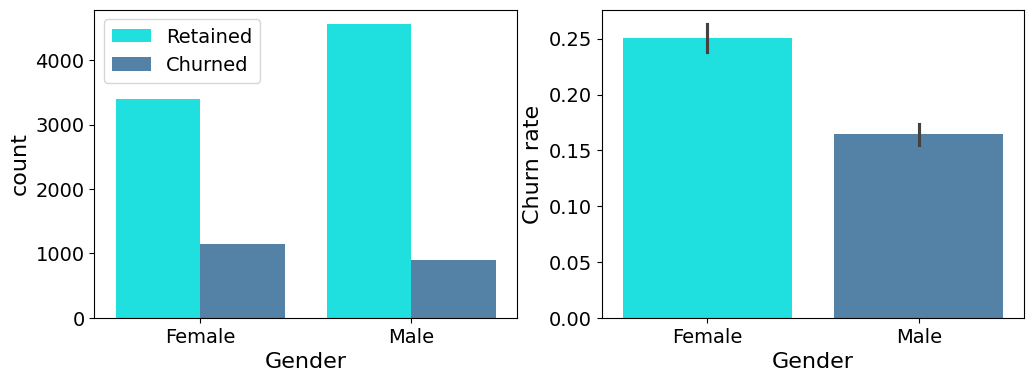

In [109]:
plot_categorical('Gender')

C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\2361493296.py:4: UserWarning: The palette list has more values (11) than needed (2), which may not be intended.
  sns.countplot(x=feature,
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\2361493296.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature,


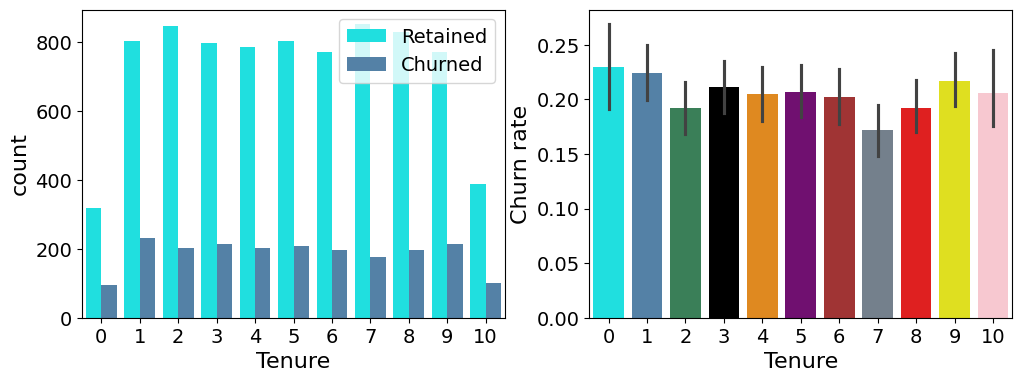

In [110]:
plot_categorical('Tenure')

C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\2361493296.py:4: UserWarning: The palette list has more values (11) than needed (2), which may not be intended.
  sns.countplot(x=feature,
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\2361493296.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature,
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\2361493296.py:12: UserWarning: The palette list has more values (11) than needed (4), which may not be intended.
  sns.barplot(x=feature,


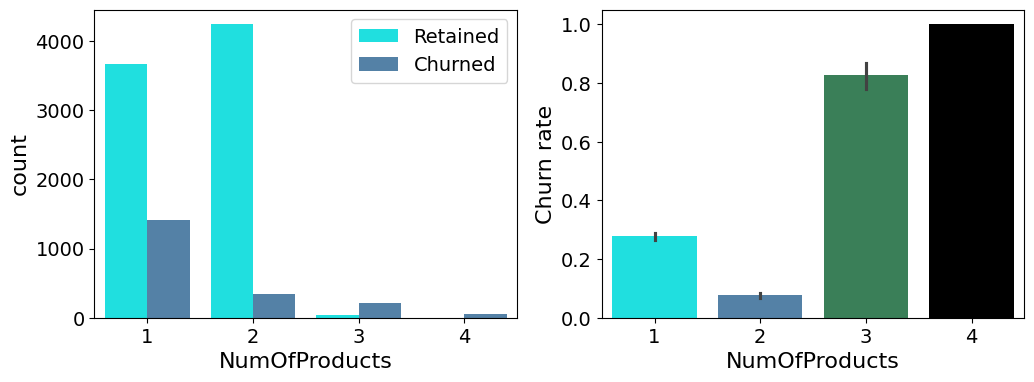

In [111]:
plot_categorical('NumOfProducts')

C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\2361493296.py:4: UserWarning: The palette list has more values (11) than needed (2), which may not be intended.
  sns.countplot(x=feature,
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\2361493296.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature,
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\2361493296.py:12: UserWarning: The palette list has more values (11) than needed (2), which may not be intended.
  sns.barplot(x=feature,
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\2361493296.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['No','Yes'])
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\2361493296.py:21: UserWarning: set_ticklabels() should only be us

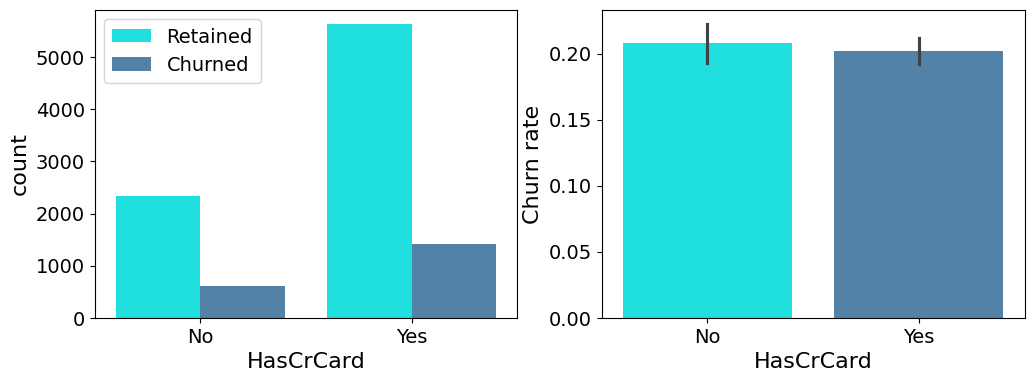

In [112]:
plot_categorical('HasCrCard')

C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\2361493296.py:4: UserWarning: The palette list has more values (11) than needed (2), which may not be intended.
  sns.countplot(x=feature,
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\2361493296.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature,
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\2361493296.py:12: UserWarning: The palette list has more values (11) than needed (2), which may not be intended.
  sns.barplot(x=feature,
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\2361493296.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['No','Yes'])
C:\Users\kriti\AppData\Local\Temp\ipykernel_23868\2361493296.py:21: UserWarning: set_ticklabels() should only be us

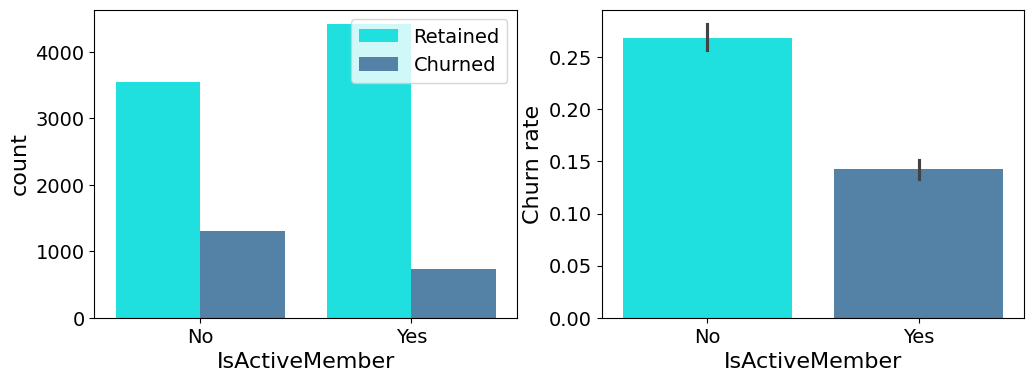

In [113]:
plot_categorical('IsActiveMember')

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [3]:
df = pd.read_csv('European_Bank.csv')
df.head()

,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Year             10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

In [7]:
df.head()

,Year,CustomerId,Surname,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,2025,15634602,Hargrave,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,2025,15647311,Hill,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,2025,15619304,Onio,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,2025,15701354,Boni,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,2025,15737888,Mitchell,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [21]:
features=['CreditScore','Gender','Age','Tenure','Balance','NumOfProducts',
          'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_Germany', 'Geography_Spain']
x = df[features]
y = df['Exited']

In [22]:
x_train, x_test, y_train, y_test = train_test_split(x, y , test_size=0.2, random_state=42)

In [23]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [24]:
x_train[:5],x_test[:5]

(array([[ 0.35649971,  0.91324755, -0.6557859 ,  0.34567966, -1.21847056,
          0.80843615,  0.64920267,  0.97481699,  1.36766974, -0.57946723,
         -0.57638802],
        [-0.20389777,  0.91324755,  0.29493847, -0.3483691 ,  0.69683765,
          0.80843615,  0.64920267,  0.97481699,  1.6612541 ,  1.72572313,
         -0.57638802],
        [-0.96147213,  0.91324755, -1.41636539, -0.69539349,  0.61862909,
         -0.91668767,  0.64920267, -1.02583358, -0.25280688, -0.57946723,
          1.73494238],
        [-0.94071667, -1.09499335, -1.13114808,  1.38675281,  0.95321202,
         -0.91668767,  0.64920267, -1.02583358,  0.91539272, -0.57946723,
         -0.57638802],
        [-1.39733684,  0.91324755,  1.62595257,  1.38675281,  1.05744869,
         -0.91668767, -1.54035103, -1.02583358, -1.05960019, -0.57946723,
         -0.57638802]]),
 array([[-0.57749609,  0.91324755, -0.6557859 , -0.69539349,  0.32993735,
          0.80843615, -1.54035103, -1.02583358, -1.01960511,  1.72572

In [26]:
model = RandomForestClassifier(n_estimators=100 , random_state=42)
model.fit(x_train, y_train)

RandomForestClassifier(random_state=42)

In [27]:
y_pred = model.predict(x_test)

In [28]:
conf_matrix = confusion_matrix(y_test , y_pred)
class_report = classification_report(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

In [29]:
print(conf_matrix)
print(class_report)
print(accuracy)

[[1551   56]
 [ 211  182]]
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.76      0.46      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000

0.8665


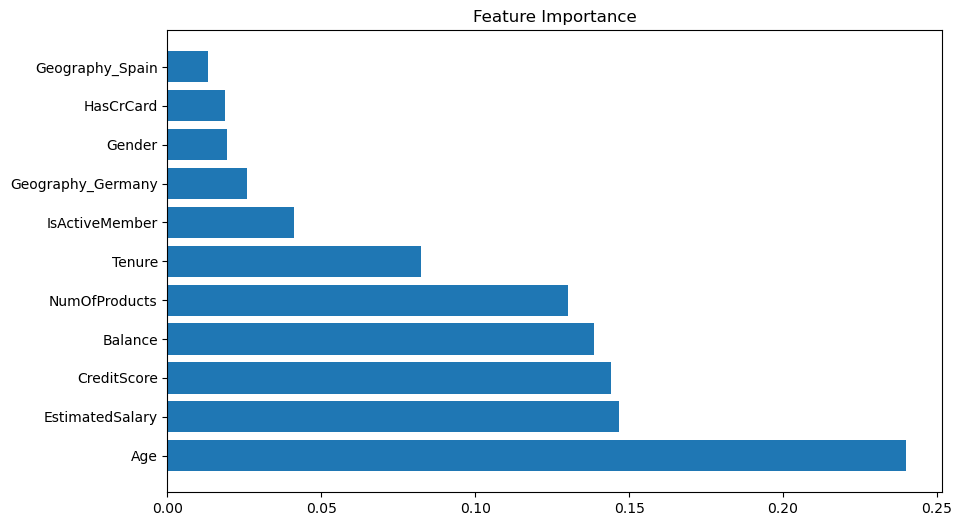

In [31]:
importances = model.feature_importances_
inddices = np.argsort(importances)[::-1]
names = [features[i] for i in inddices]

plt.figure(figsize=(10,6))
plt.title('Feature Importance')
plt.barh(range(x.shape[1]), importances[inddices])
plt.yticks(range(x.shape[1]), names)
plt.show()

In [33]:
from sklearn.linear_model import LogisticRegression

#Build and train the Logistic Regression model
log_reg = LogisticRegression(random_state=42)
log_reg.fit(x_train,y_train)

# Make Predicyions
y_pred_log_reg = log_reg.predict(x_test)

#Evaluate the model
conf_matrix_log_reg = confusion_matrix(y_test, y_pred_log_reg)
class_report_log_reg = classification_report(y_test, y_pred_log_reg)
accuracy_log_reg = accuracy_score(y_test, y_pred_log_reg)

print(conf_matrix_log_reg, class_report_log_reg, accuracy_log_reg )


[[1543   64]
 [ 314   79]]               precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000
 0.811


In [36]:
from sklearn.tree import DecisionTreeClassifier

#Build and train the Logistic Regression model
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(x_train,y_train)

# Make Predicyions
y_pred_dt = dt_model.predict(x_test)

#Evaluate the model
conf_matrix_dt = confusion_matrix(y_test, y_pred_dt)
class_report_dt = classification_report(y_test, y_pred_dt)
accuracy_dt = accuracy_score(y_test, y_pred_dt)

print(conf_matrix_dt, class_report_dt, accuracy_dt )

[[1371  236]
 [ 196  197]]               precision    recall  f1-score   support

           0       0.87      0.85      0.86      1607
           1       0.45      0.50      0.48       393

    accuracy                           0.78      2000
   macro avg       0.66      0.68      0.67      2000
weighted avg       0.79      0.78      0.79      2000
 0.784


In [37]:
from sklearn.neighbors import KNeighborsClassifier

#Build and train the Logistic Regression model
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(x_train,y_train)

# Make Predicyions
y_pred_knn = knn_model.predict(x_test)

#Evaluate the model
conf_matrix_knn = confusion_matrix(y_test, y_pred_knn)
class_report_knn = classification_report(y_test, y_pred_knn)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print(conf_matrix_knn, class_report_knn, accuracy_knn)

[[1514   93]
 [ 247  146]]               precision    recall  f1-score   support

           0       0.86      0.94      0.90      1607
           1       0.61      0.37      0.46       393

    accuracy                           0.83      2000
   macro avg       0.74      0.66      0.68      2000
weighted avg       0.81      0.83      0.81      2000
 0.83


In [38]:
from sklearn.ensemble import GradientBoostingClassifier

#Build and train the Logistic Regression model
gbm_model = GradientBoostingClassifier(n_estimators=100 , random_state=42)
gbm_model.fit(x_train,y_train)

# Make Predicyions
y_pred_gbm = gbm_model.predict(x_test)

#Evaluate the model
conf_matrix_gbm = confusion_matrix(y_test, y_pred_gbm)
class_report_gbm = classification_report(y_test, y_pred_gbm)
accuracy_gbm = accuracy_score(y_test, y_pred_gbm)

print(conf_matrix_gbm, class_report_gbm, accuracy_gbm)

[[1543   64]
 [ 201  192]]               precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.75      0.49      0.59       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.76      2000
weighted avg       0.86      0.87      0.86      2000
 0.8675


In [43]:
df = pd.read_csv('European_Bank.csv')

# Binary feature for balance
df['BalanceZero'] = (df['Balance'] == 0).astype(int)

# Age groups
df['AgeGroup'] = pd.cut(df['Age'], bins=[18,25,35,45,55,65,75,85,95],labels=['18-25','26-35','36-45','46-55','56-65','66-75','76-85','86-95'])

# Balance to Salary Ratio
df['BalanceToSalaryRatio'] = df['Balance'] / df['EstimatedSalary']

# Interaction feature between NumOfProducts and IsActiveMember
df['ProductUsage'] = df['NumOfProducts']  * df['IsActiveMember']

# Tenure Grouping
df['TenureGroup'] = pd.cut(df['Tenure'], bins=[0,2,5,7,10], labels=['0-2','3-5','6-7','8-10'])


In [44]:
label_encoder = LabelEncoder()
df['Gender'] = label_encoder.fit_transform(df['Gender'])
df = pd.get_dummies(df, columns=['Geography'], drop_first=True)
df['Male_Germany'] = df['Gender'] * df['Geography_Germany']
df['Male_Spain'] = df['Gender'] * df['Geography_Spain']

In [45]:
df =pd.get_dummies(df, columns=['AgeGroup','TenureGroup'], drop_first=True)

In [47]:
df.columns

Index(['Year', 'CustomerId', 'Surname', 'CreditScore', 'Gender', 'Age',
       'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember',
       'EstimatedSalary', 'Exited', 'BalanceZero', 'BalanceToSalaryRatio',
       'ProductUsage', 'Geography_Germany', 'Geography_Spain', 'Male_Germany',
       'Male_Spain', 'AgeGroup_26-35', 'AgeGroup_36-45', 'AgeGroup_46-55',
       'AgeGroup_56-65', 'AgeGroup_66-75', 'AgeGroup_76-85', 'AgeGroup_86-95',
       'TenureGroup_3-5', 'TenureGroup_6-7', 'TenureGroup_8-10'],
      dtype='object')

In [48]:
features = ['CreditScore','Age', 'Tenure', 'Balance', 'NumOfProducts', 
           'HasCrCard', 'IsActiveMember','EstimatedSalary', 'Geography_Germany',
           'Geography_Spain', 'BalanceZero', 'BalanceToSalaryRatio', 'ProductUsage',
           'Male_Germany', 'Male_Spain'] + [col for col in df.columns if 'AgeGroup_' in col or ' TenureGroup_' in col]
x = df[features]
y= df['Exited']
     

In [49]:
x_train, x_test,y_train, y_test = train_test_split(x,y , test_size=0.2, random_state=42)

In [50]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

In [51]:
conf_matrix = confusion_matrix(y_test, y_pred)
class_report= classification_report(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

In [52]:
print(conf_matrix)
print(class_report)
print(accuracy)

[[1548   59]
 [ 208  185]]
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1607
           1       0.76      0.47      0.58       393

    accuracy                           0.87      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.86      0.87      0.85      2000

0.8665
